# The Broden Dataset

Selects 3 random concepts based on filename prefixes (excluding `_color`), plots 5 images per concept, and draws separator lines between concept rows.

In [17]:
import os
import random
from PIL import Image

# Path to the Broden DTD images directory
images_dir = 'broden1_224/images/dtd'

# List all image files, excluding color suffixes
files = [f for f in os.listdir(images_dir)
         if f.lower().endswith(('.png', '.jpg', '.jpeg'))
         and not f.lower().endswith('_color.png')
         and not f.lower().endswith('_color.jpg')
         and not f.lower().endswith('_color.jpeg')]

# Extract concepts
concepts = list({f.split('_')[0] for f in files})
selected_concepts = random.sample(concepts, min(3, len(concepts)))
samples = {}
for concept in selected_concepts:
    concept_files = [f for f in files if f.startswith(concept + '_')]
    samples[concept] = random.sample(concept_files, min(5, len(concept_files)))
    print(f"{concept}: sampled {len(samples[concept])} images")


chequered: sampled 5 images
stained: sampled 5 images
marbled: sampled 5 images


## Plot the Mosaic with Separators


Saved mosaic with separators as broden_random.pdf


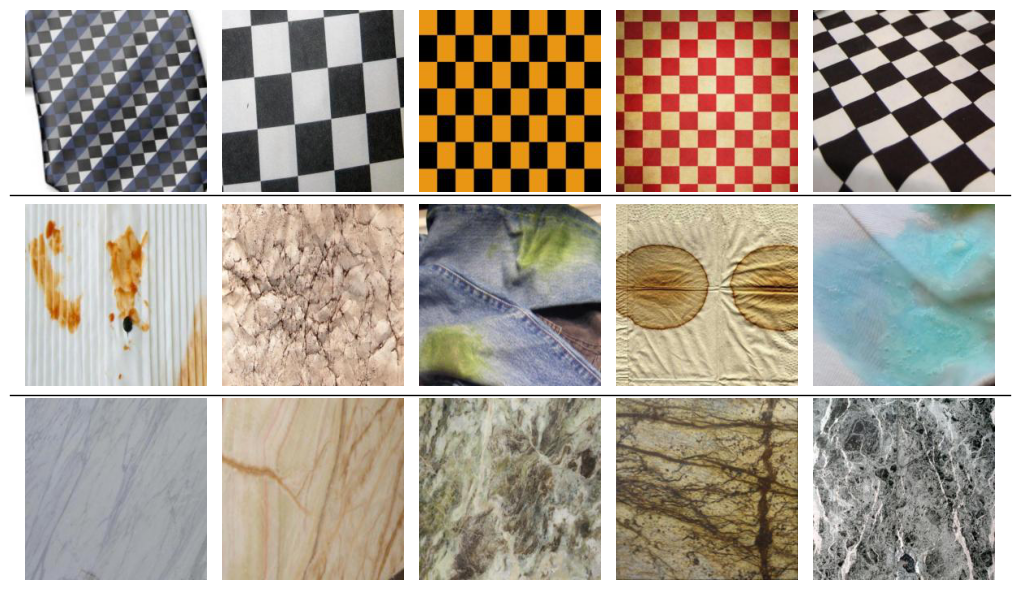

In [18]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

n_rows = len(selected_concepts)
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))

for i, concept in enumerate(selected_concepts):
    for j in range(n_cols):
        ax = axes[i, j] if n_rows > 1 else axes[j]
        ax.axis('off')
        img = Image.open(os.path.join(images_dir, samples[concept][j]))
        ax.imshow(img)
        if j == 0:
            ax.set_ylabel(concept.capitalize(), fontsize=10)

# Draw horizontal separator lines between rows
for k in range(1, n_rows):
    # y position in figure coordinates
    y = 1 - k / n_rows
    line = Line2D([0, 1], [y, y], transform=fig.transFigure, color='black', linewidth=1)
    fig.add_artist(line)

plt.tight_layout()
output_file = 'broden_random.pdf'
fig.savefig(output_file, format='pdf')
print(f'Saved mosaic with separators as {output_file}')